# Autoencoder (AE) - TensorFlow / Keras

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape: (10000, 784)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2494 - val_loss: 0.1677
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1503 - val_loss: 0.1365
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1312 - val_loss: 0.1237
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.1215 - val_loss: 0.1167
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1156 - val_loss: 0.1120
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1114 - val_loss: 0.1086
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1080 - val_loss: 0.1051
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1054 - val_loss: 0.1026
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1031 - val_loss: 0.1011
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1013 - val_loss: 0.0990
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0997 - val_loss: 0.0980
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

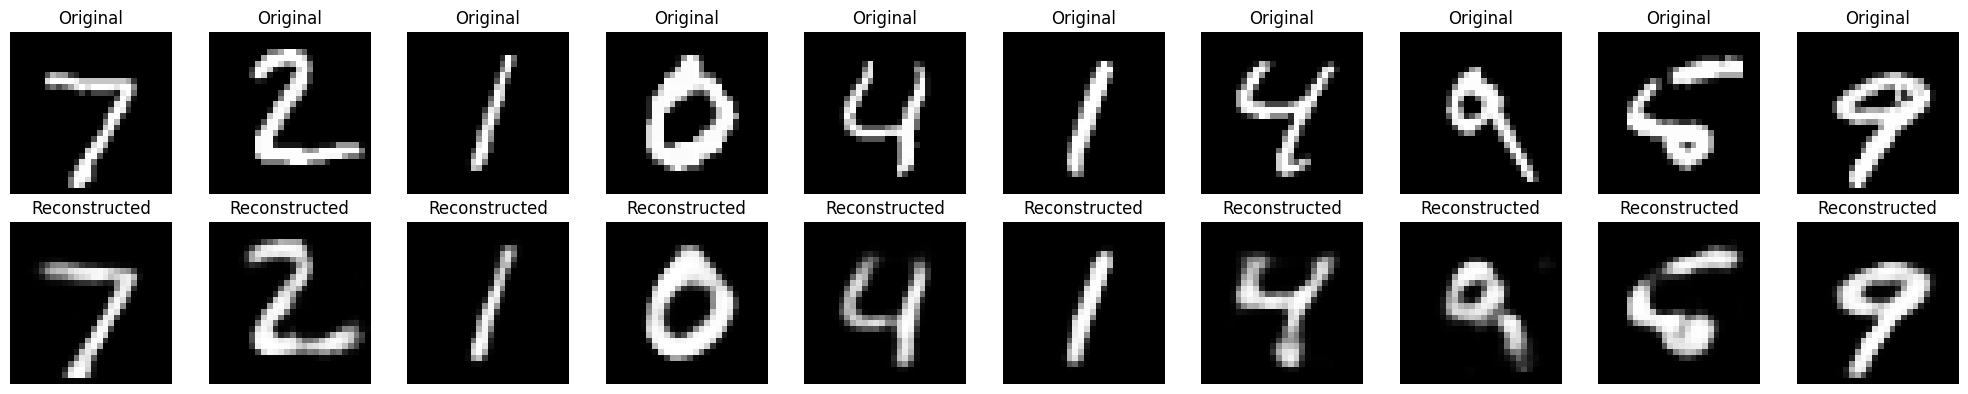

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 32)
Sample encoded vector:
 [ 7.524696  10.983955   5.569586   9.526578   5.739855  10.871973
 21.273787   5.059826  10.27495   18.577028   7.649909   8.388565
  5.0159187  0.         8.575718   6.9284005  0.        18.284668
  0.        13.375276   9.2600155  8.384185   4.9433208 13.650211
  6.3721247 10.903925   0.        18.977556  14.646737   7.4941344
  6.8520226 13.13776  ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# =========================
# 1. Load Dataset
# =========================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values (0 to 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images: 28x28 -> 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# =========================
# 2. Define Autoencoder
# =========================

input_dim = 784
encoding_dim = 32   # Compressed representation

# Encoder
input_img = Input(shape=(input_dim,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded_output = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(encoded_output)
decoded = Dense(128, activation='relu')(decoded)
decoded_output = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder Model
autoencoder = Model(input_img, decoded_output)

# Separate Encoder Model
encoder = Model(input_img, encoded_output)

# =========================
# 3. Compile Model
# =========================
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

# =========================
# 4. Train Model
# =========================
history = autoencoder.fit(
    x_train,
    x_train,   # Target is same as input
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# =========================
# 5. Reconstruct Images
# =========================
decoded_imgs = autoencoder.predict(x_test)

# =========================
# 6. Visualize Results
# =========================
n = 10  # Number of digits to display

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 7. Encode Sample Images
# =========================
encoded_imgs = encoder.predict(x_test)

print("Encoded shape:", encoded_imgs.shape)
print("Sample encoded vector:\n", encoded_imgs[0])